In [ ]:
df.columns.to_list()

['city',
 'quarter',
 'rent',
 'hpi',
 'rent_growth',
 'hpi_growth',
 'valuation_gap',
 'repo_rate',
 'hpi_lag',
 'rent_lag',
 'repo_growth',
 'repo_lag',
 'year_quarter',
 'repo_growth_ma4',
 'repo_growth_ma2',
 'regime']

In [ ]:
df.columns.to_list()

['city',
 'quarter',
 'rent',
 'hpi',
 'rent_growth',
 'hpi_growth',
 'valuation_gap',
 'repo_rate',
 'hpi_lag',
 'rent_lag',
 'repo_growth',
 'repo_lag',
 'year_quarter',
 'repo_growth_ma4',
 'repo_growth_ma2',
 'regime']

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/final_model_dataset.csv')
display(df.head())

,city,quarter,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,repo_lag
0,bangalore,Q1 2015,104.4500,61.806841,0.043538,0.237475,-0.193937,7.782887,NaN,NaN,NaN,NaN
1,bangalore,Q1 2016,114.6000,71.406332,0.092739,0.144372,-0.051633,7.657853,0.237475,0.043538,-0.016196,NaN
2,bangalore,Q1 2017,121.9875,75.582470,0.062471,0.056838,0.005633,6.962920,0.144372,0.092739,-0.095133,-0.016196
3,bangalore,Q1 2018,145.2250,77.997789,0.174366,0.031456,0.142910,7.466353,0.056838,0.062471,0.069808,-0.095133
4,bangalore,Q1 2019,144.7375,83.885498,-0.003363,0.072772,-0.076135,7.397403,0.031456,0.174366,-0.009278,0.069808


In [ ]:
display(df.describe())

,rent,hpi,rent_growth,hpi_growth,valuation_gap,repo_rate,hpi_lag,rent_lag,repo_growth,repo_lag
count,175.000000,175.000000,175.000000,175.000000,175.000000,167.000000,171.000000,171.000000,161.000000,157.000000
mean,130.633449,93.294346,0.033041,0.053317,-0.020276,7.064108,0.008345,0.006289,-0.017218,-0.009859
std,24.404011,17.149197,0.073448,0.089757,0.103587,0.570082,0.197581,0.134513,0.096505,0.104470
min,94.500000,59.203005,-0.273759,-0.300430,-0.478007,5.910980,-0.980377,-0.666421,-0.165880,-0.165880
25%,110.600000,78.777559,-0.002539,0.000469,-0.078284,6.676732,-0.007579,-0.016117,-0.088565,-0.094899
50%,124.300000,95.690968,0.038898,0.061195,-0.024529,7.119050,0.050597,0.034501,-0.034087,-0.033334
75%,144.256250,103.979883,0.074434,0.105878,0.046676,7.405995,0.103158,0.069209,0.072876,0.074205
max,203.675000,146.223219,0.277253,0.275671,0.230875,8.791340,0.259346,0.277253,0.263040,0.263040


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a sortable quarter column for chronological plotting
df['year_quarter'] = df['quarter'].str.extract(r'Q(\d) (\d{4})').astype(int).pipe(lambda x: x[1] * 4 + x[0] - 1)
df = df.sort_values(by=['city', 'year_quarter'])

### Average Rent and HPI by City

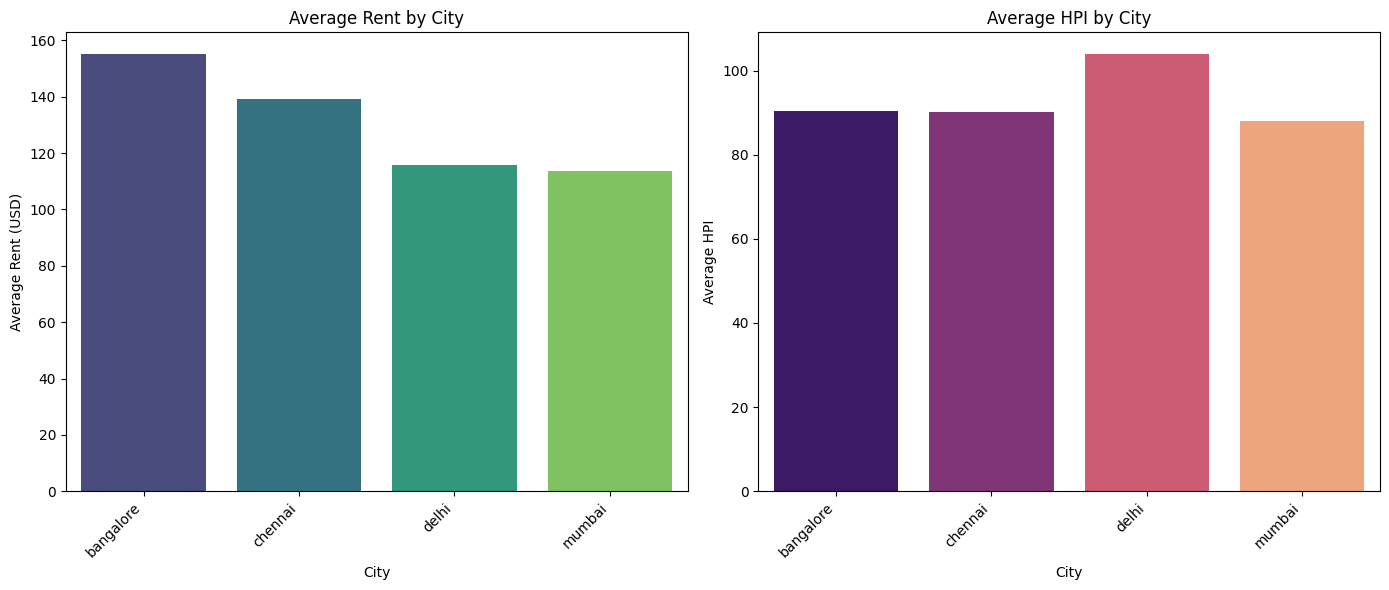

In [ ]:
# Calculate average rent and HPI by city
avg_by_city = df.groupby('city')[['rent', 'hpi']].mean().reset_index()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='city', y='rent', hue='city', data=avg_by_city, palette='viridis', legend=False)
plt.title('Average Rent by City')
plt.ylabel('Average Rent (USD)')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x='city', y='hpi', hue='city', data=avg_by_city, palette='magma', legend=False)
plt.title('Average HPI by City')
plt.ylabel('Average HPI')
plt.xlabel('City')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Rent and HPI Trends Over Quarters per City

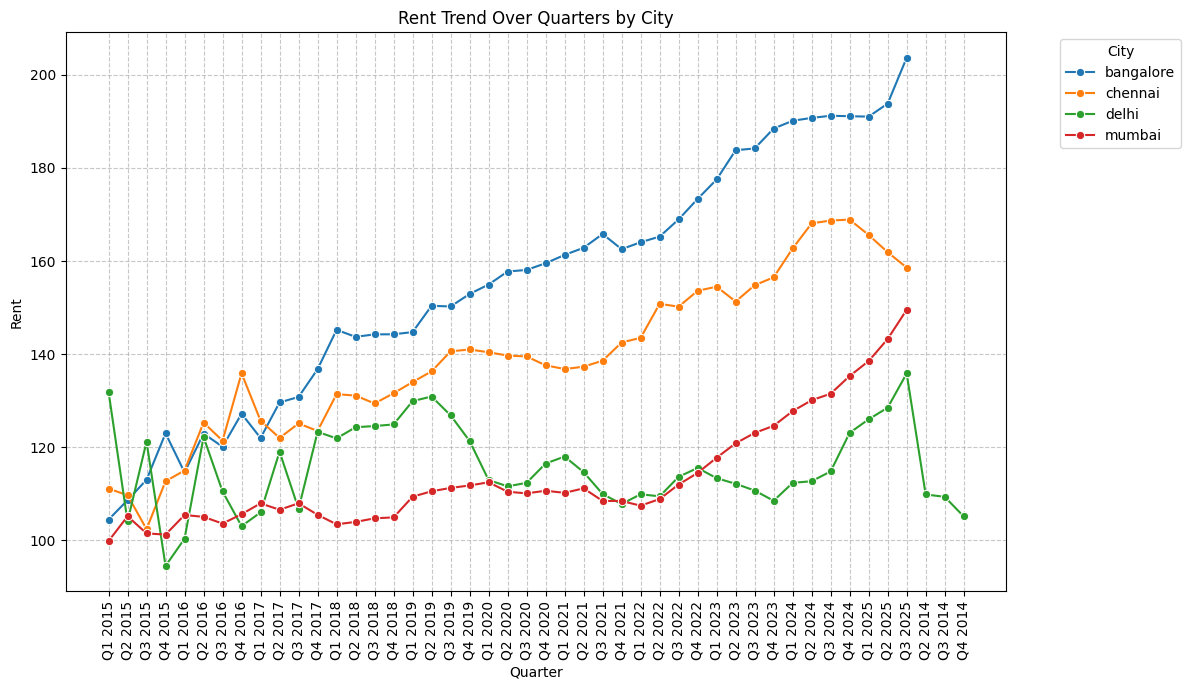

In [ ]:
# Line plot for Rent trends by Quarter and City
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='rent', hue='city', data=df, marker='o')
plt.title('Rent Trend Over Quarters by City')
plt.ylabel('Rent')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

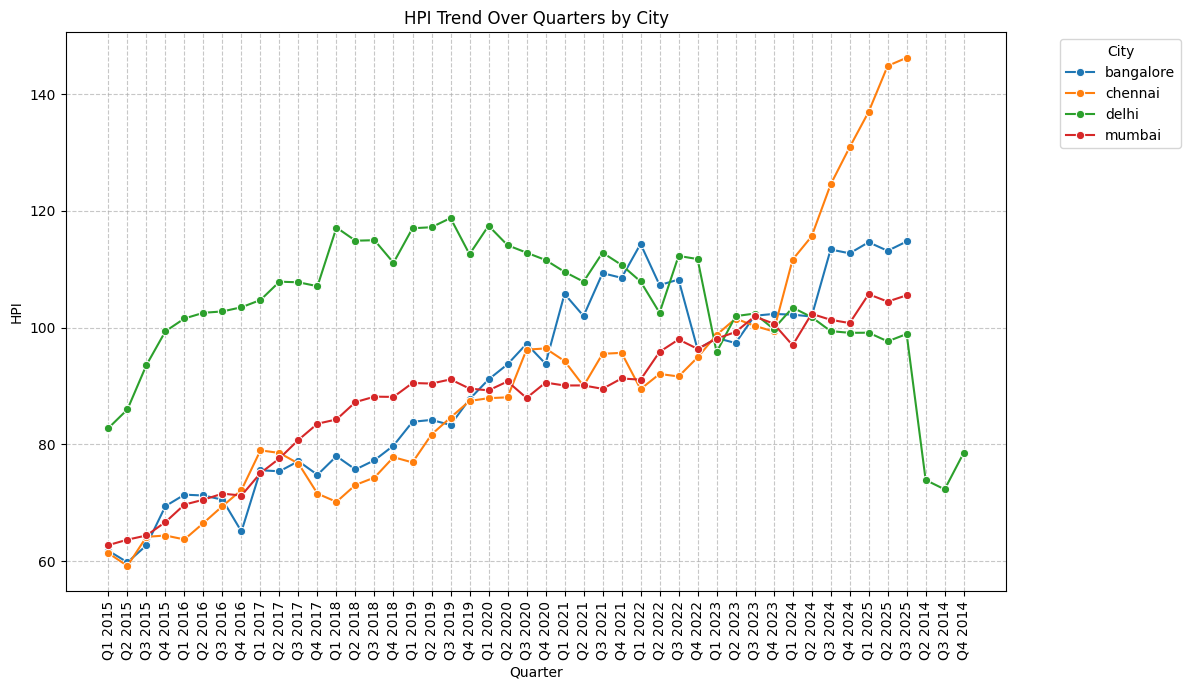

In [ ]:
# Line plot for HPI trends by Quarter and City
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='hpi', hue='city', data=df, marker='o')
plt.title('HPI Trend Over Quarters by City')
plt.ylabel('HPI')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Repo Growth Trend Over Quarters

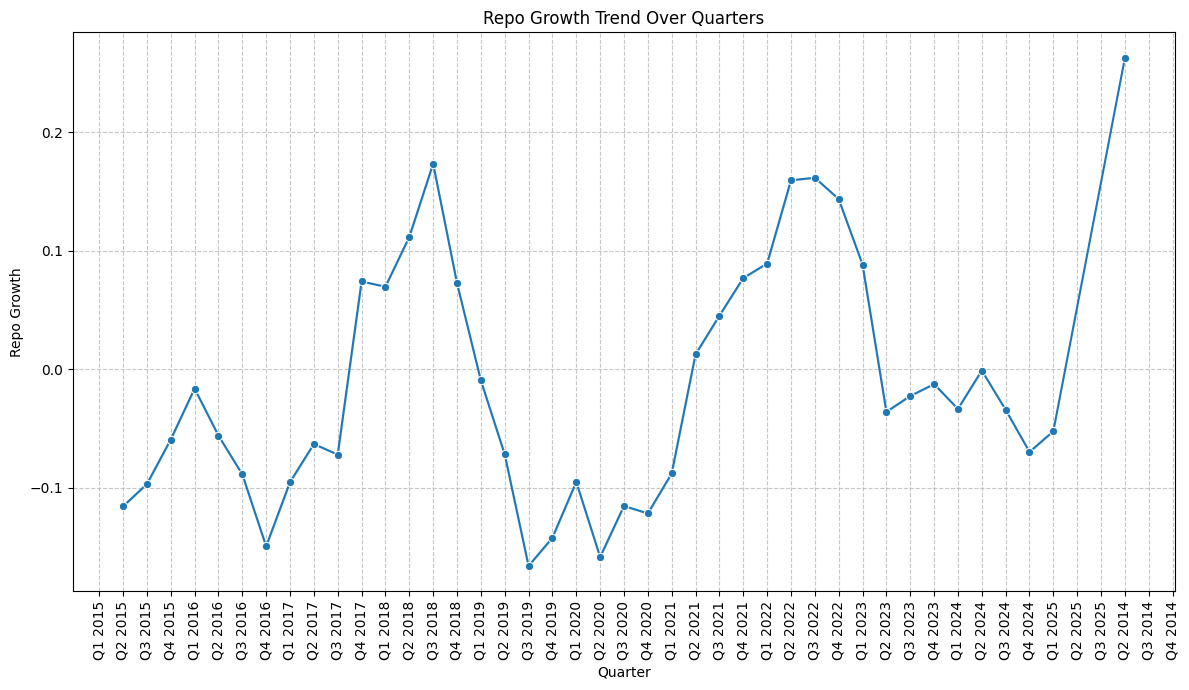

In [ ]:
# Line plot for Repo Growth trends by Quarter
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='repo_growth', data=df, marker='o')
plt.title('Repo Growth Trend Over Quarters')
plt.ylabel('Repo Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Repo Lag Trend Over Quarters

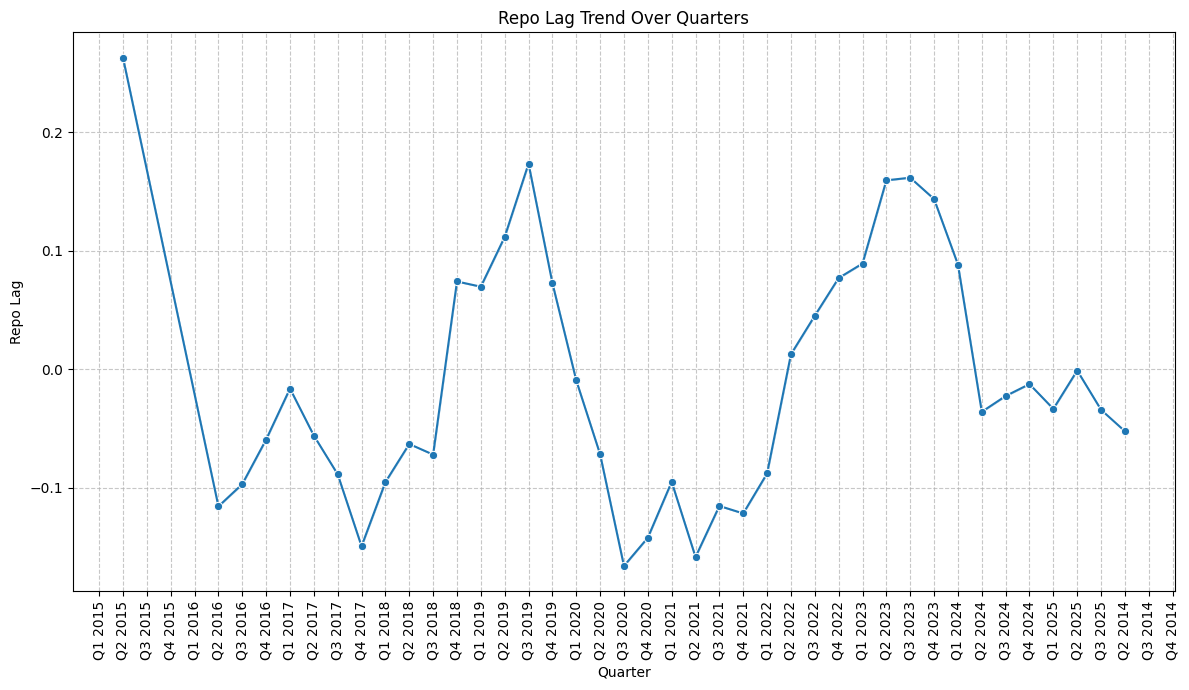

In [ ]:
# Line plot for Repo Lag trends by Quarter
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='repo_lag', data=df, marker='o')
plt.title('Repo Lag Trend Over Quarters')
plt.ylabel('Repo Lag')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Moving Average of Repo Growth

In [ ]:
df['repo_growth_ma2'] = df.groupby('city')['repo_growth'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
display(df[['city', 'quarter', 'repo_growth', 'repo_growth_ma2']].head())

,city,quarter,repo_growth,repo_growth_ma2
0,bangalore,Q1 2015,NaN,NaN
11,bangalore,Q2 2015,-0.115619,-0.115619
22,bangalore,Q3 2015,-0.096838,-0.106228
33,bangalore,Q4 2015,-0.059205,-0.078021
1,bangalore,Q1 2016,-0.016196,-0.037700


First, we will calculate `hpi_lag` as the previous quarter's HPI, grouped by city, and then create the `regime` variable using `pd.qcut`.

In [ ]:
df['hpi_lag'] = df.groupby('city')['hpi'].shift(1)
df['regime'] = pd.qcut(df['hpi_lag'], q=3, labels=['low', 'mid', 'high'], duplicates='drop')
display(df[['city', 'quarter', 'hpi', 'hpi_lag', 'regime']].head())

,city,quarter,hpi,hpi_lag,regime
0,bangalore,Q1 2015,61.806841,NaN,NaN
11,bangalore,Q2 2015,59.819703,61.806841,low
22,bangalore,Q3 2015,62.725676,59.819703,low
33,bangalore,Q4 2015,69.447592,62.725676,low
1,bangalore,Q1 2016,71.406332,69.447592,low


To proceed with plotting, please provide the definition or formula for 'Valuation Gap'. Once I have that, I can generate the requested plot.

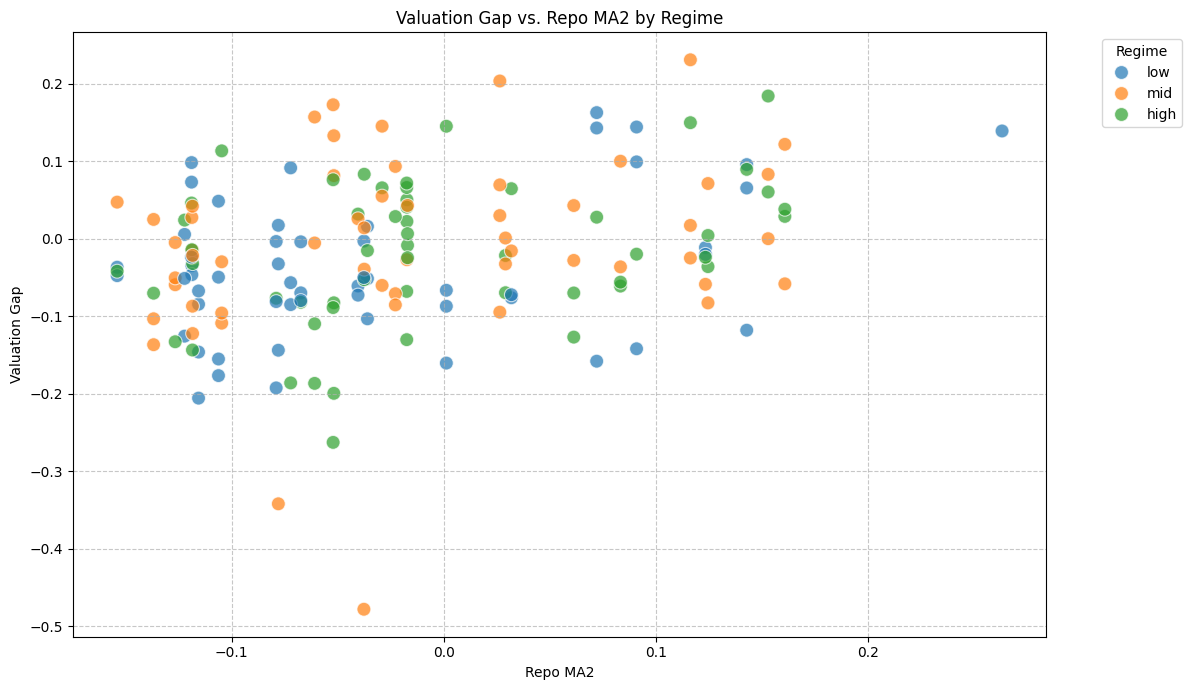

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='repo_growth_ma2', y='valuation_gap', hue='regime', data=df, s=100, alpha=0.7)
plt.title('Valuation Gap vs. Repo MA2 by Regime')
plt.xlabel('Repo MA2')
plt.ylabel('Valuation Gap')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Regime', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

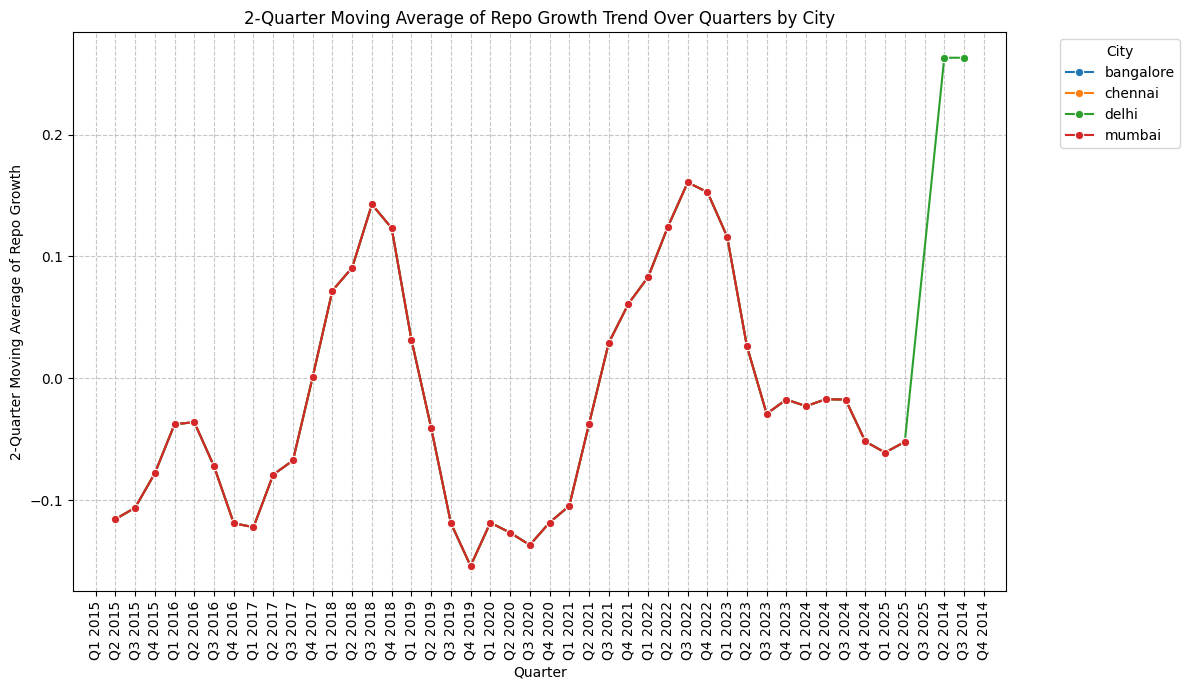

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(x='quarter', y='repo_growth_ma2', hue='city', data=df, marker='o')
plt.title('2-Quarter Moving Average of Repo Growth Trend Over Quarters by City')
plt.ylabel('2-Quarter Moving Average of Repo Growth')
plt.xlabel('Quarter')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

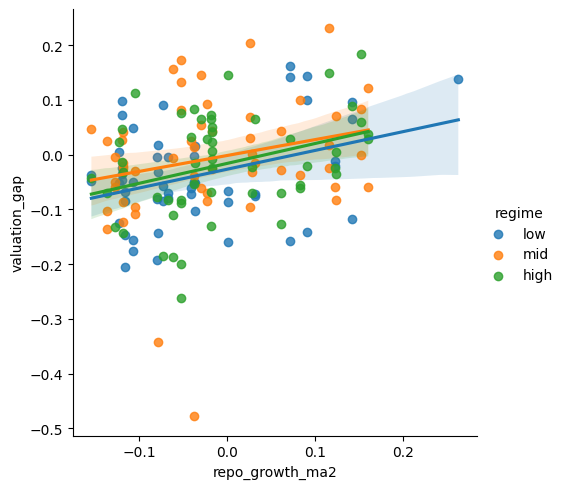

In [ ]:
sns.lmplot(
    data=df,
    x="repo_growth_ma2",
    y="valuation_gap",
    hue="regime"
)

In [ ]:
import pandas as pd

# Check if arch is installed, if not, install it.
try:
    import arch
except ImportError:
    print("The 'arch' library is not installed. Installing now...")
    !pip install arch
    import arch

# Extract the 'valuation_gap' series.
# GARCH models typically require a stationary series, often applied to residuals or returns.
# Modeling valuation_gap directly might require a mean model (e.g., Constant, AR(p))
# If valuation_gap itself is not stationary, the GARCH results might be misleading.
# For this request, we will directly model the series as requested.

valuation_gap_series = df['valuation_gap'].dropna()

if valuation_gap_series.empty:
    print("The 'valuation_gap' series is empty or contains only NaNs after dropping.")
elif len(valuation_gap_series) < 5: # GARCH usually needs more data points for reliable fitting
    print(f"Not enough data points ({len(valuation_gap_series)}) to fit a reliable GARCH model after dropping NaNs. Minimum 5-10 recommended.")
else:
    print(f"Fitting GARCH(1,1) model to 'valuation_gap' series with {len(valuation_gap_series)} data points.")
    # Fit a GARCH(1,1) model
    # 'vol' specifies the conditional variance model (GARCH)
    # 'p' is the order of the AR term in the variance model (ARCH)
    # 'q' is the order of the MA term in the variance model (GARCH)
    # 'mean' can be 'Constant', 'ARX', 'HARX', etc. For simplicity and direct interpretation, 'Constant' is a common start.
    model = arch.arch_model(valuation_gap_series, mean='Constant', vol='Garch', p=1, q=1, dist='normal')

    # Fit the model, 'disp='off'' suppresses optimization output
    try:
        results = model.fit(disp='off')
        print(results.summary())
        print("\nNote: GARCH models are typically applied to the residuals of a mean model (e.g., ARMA) "
              "or to asset returns, as the underlying series should ideally be stationary. "
              "If 'valuation_gap' is not stationary, consider differencing or fitting a mean model first.")
    except Exception as e:
        print(f"An error occurred during model fitting: {e}")

The 'arch' library is not installed. Installing now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 4.5 MB/s eta 0:00:00
Fitting GARCH(1,1) model to 'valuation_gap' series with 175 data points.
                     Constant Mean - GARCH Model Results                      
Dep. Variable:          valuation_gap   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                172.642
Distribution:                  Normal   AIC:                          -337.284
Method:            Maximum Likelihood   BIC:                          -324.625
                                        No. Observations:                  175
Date:                Fri, May 01 2026   Df Residuals:                      174
Time:                        13:23:30   Df Model:                            1
                                  Mean Model                                 
   

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01067. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


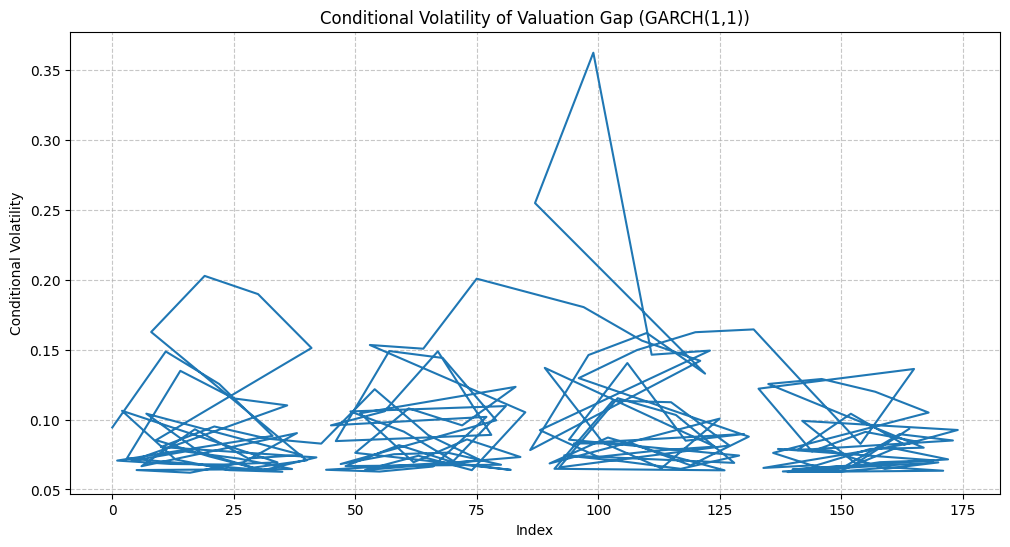

In [23]:
if 'results' in locals():
    plt.figure(figsize=(12, 6))
    plt.plot(valuation_gap_series.index, results.conditional_volatility)
    plt.title('Conditional Volatility of Valuation Gap (GARCH(1,1))')
    plt.xlabel('Index')
    plt.ylabel('Conditional Volatility')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("GARCH model results not found. Please run the GARCH fitting cell first.")

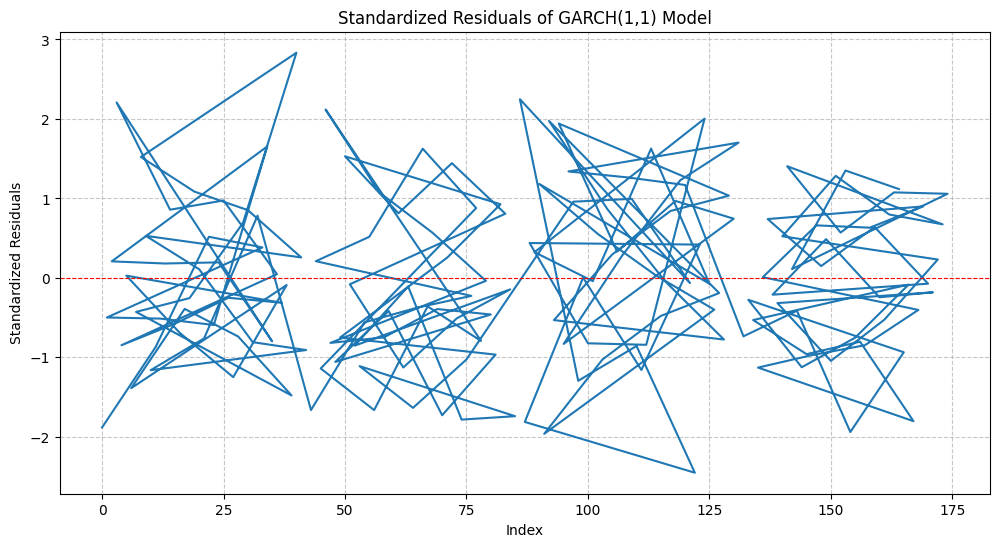

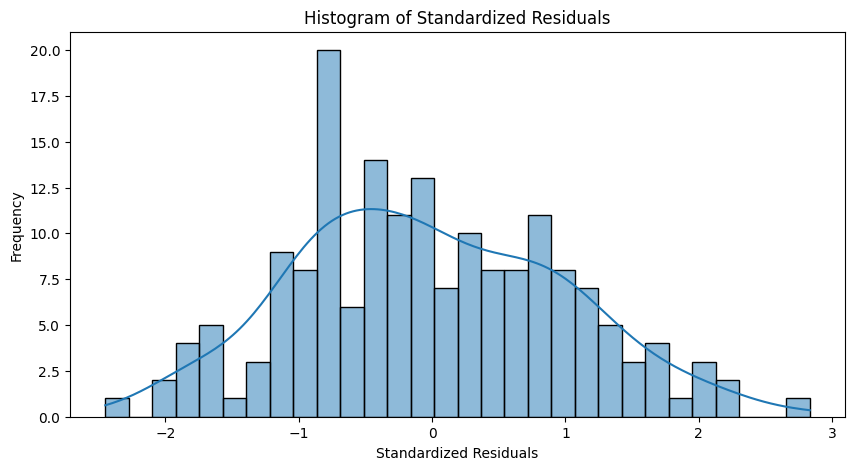

In [24]:
if 'results' in locals():
    standardized_residuals = results.std_resid

    plt.figure(figsize=(12, 6))
    plt.plot(valuation_gap_series.index, standardized_residuals)
    plt.title('Standardized Residuals of GARCH(1,1) Model')
    plt.xlabel('Index')
    plt.ylabel('Standardized Residuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
    plt.show()

    # Also plot a histogram of residuals to check for normality
    plt.figure(figsize=(10, 5))
    sns.histplot(standardized_residuals, kde=True, bins=30)
    plt.title('Histogram of Standardized Residuals')
    plt.xlabel('Standardized Residuals')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("GARCH model results not found. Please run the GARCH fitting cell first.")

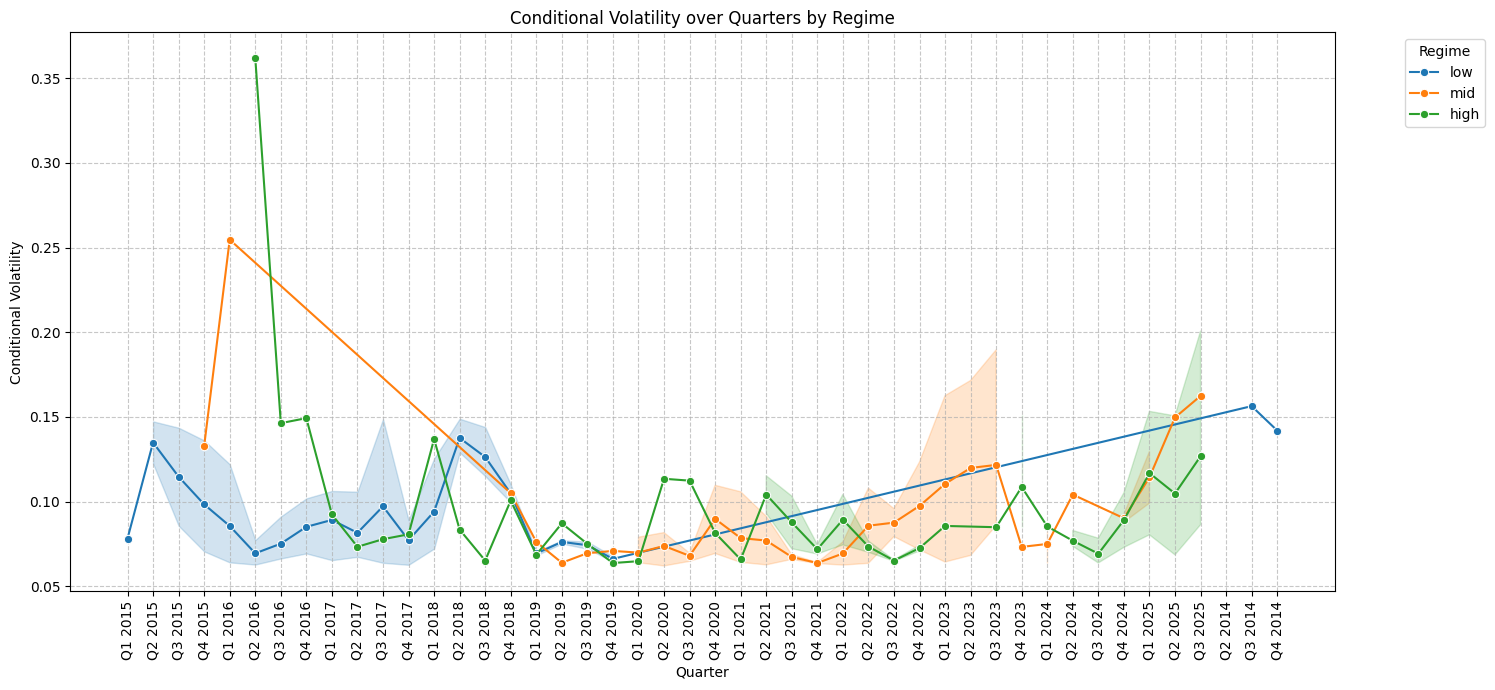

In [25]:
if 'results' in locals() and 'df' in globals():
    # Get conditional volatility and align its index with original df
    conditional_volatility = results.conditional_volatility

    # Create a temporary DataFrame for plotting by joining conditional_volatility with relevant df columns
    # Ensure the index aligns
    plot_df = df.loc[conditional_volatility.index].copy()
    plot_df['conditional_volatility'] = conditional_volatility

    # The original df is already sorted by 'city' and 'year_quarter', so plot_df should maintain this order.
    # However, explicitly sorting again ensures chronological order if any prior operations disturbed it.
    plot_df = plot_df.sort_values(by=['city', 'year_quarter'])

    plt.figure(figsize=(15, 7))
    sns.lineplot(data=plot_df, x='quarter', y='conditional_volatility', hue='regime', marker='o')
    plt.title('Conditional Volatility over Quarters by Regime')
    plt.xlabel('Quarter')
    plt.ylabel('Conditional Volatility')
    plt.xticks(rotation=90)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Regime', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("GARCH model results or DataFrame not found. Please run the GARCH fitting cell and ensure 'df' is loaded.")